In [243]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
import re
from collections import Counter

#### **CONTEXTO E OBJETIVO**
* Os dados foram obtidos a partir do consumo da API da Gupy.
* O objetivo é analisar o mercado de vagas de dados dentro desse contexto. 
* Como está o mercado recentemente?

**Labels** utilizadas para obtenção de arquivos: <br>
* analista
* dados
* python
* administração
* engenharia
* desenvolvedor
* engenheiro
* cientista
* ciência
* bi
* analyst
* engineer
* scientist
* business
* devops
* back-end

In [216]:
# leitura dos múltiplos arquivos JSONS
path = Path ("../dados/vagas")

files = list(path.glob("*json"))

dfs = []

for file in files:
    df = pd.read_json(file)
    dfs.append(df)

arquivo_dados = pd.concat(dfs, ignore_index=True)
arquivo_dados.head

<bound method NDFrame.head of           id  companyId                                               name  \
0    9749257        400  Analista de Planejamento Financeiro Sr. (Foco ...   
1    9748351      23930                         ANALISTA ADMINISTRATIVO JR   
2    9740850        487                           Analista de Laboratório    
3    9738884        400             Analista de Planejamento Comercial Sr.   
4    9738834        400             Analista de Planejamento Comercial Jr.   
..       ...        ...                                                ...   
434   718626       2226                             Engenheiro(a) de Dados   
435  9741353      17527  Cientista de Dados | AWS | Python | Machine Le...   
436  9385227       7198    Pessoa Engenheira de Software - Back-end Python   
437  7407340      39703                   Analista Machine Learning/Python   
438  4738330      52441  Banco de Talentos WK Technology - Desenvolvime...   

                                 

In [217]:
df_dados = arquivo_dados[arquivo_dados["name"].str.contains("dados", case=False, na=False) |
                         arquivo_dados["description"].str.contains("dados", case=False, na=False)]
df_dados = df_dados.drop_duplicates(subset="id")
df_dados.count()

id                     179
companyId              179
name                   179
description            179
careerPageId           179
careerPageName         179
careerPageLogo         179
type                   179
publishedDate          179
applicationDeadline     29
isRemoteWork           179
city                   179
state                  179
country                179
jobUrl                 179
badges                 179
disabilities           179
workplaceType          162
careerPageUrl          179
dtype: int64

In [218]:
#df_dados

In [219]:
df_dados.columns

Index(['id', 'companyId', 'name', 'description', 'careerPageId',
       'careerPageName', 'careerPageLogo', 'type', 'publishedDate',
       'applicationDeadline', 'isRemoteWork', 'city', 'state', 'country',
       'jobUrl', 'badges', 'disabilities', 'workplaceType', 'careerPageUrl'],
      dtype='str')

In [220]:
df_dados_limpo = df_dados.drop(columns=["id","companyId", "careerPageId", "careerPageLogo",
                                   "publishedDate", "applicationDeadline", "isRemoteWork",
                                   "country","jobUrl", "badges", "disabilities", "careerPageUrl"])
df_dados_limpo

,name,description,careerPageName,type,city,state,workplaceType
0,Analista de Planejamento Financeiro Sr. (Foco ...,"Quando você pensa em carreira, o que vem à sua...",PagBank,vacancy_type_talent_pool,São Paulo,São Paulo,hybrid
2,Analista de Laboratório,Você tem paixão pelas pessoas e gosta de cuida...,Dasa,vacancy_type_talent_pool,Serra,Espírito Santo,on-site
3,Analista de Planejamento Comercial Sr.,"Quando você pensa em carreira, o que vem à sua...",PagBank,vacancy_type_talent_pool,São Paulo,São Paulo,hybrid
4,Analista de Planejamento Comercial Jr.,"Quando você pensa em carreira, o que vem à sua...",PagBank,vacancy_type_talent_pool,São Paulo,São Paulo,hybrid
5,Analista de Inteligência Comercial II | São Be...,Atuação com processos e monitoramento do compo...,Tecnogera Geradores,vacancy_type_effective,São Bernardo do Campo,São Paulo,on-site
...,...,...,...,...,...,...,...
430,Cientista de Dados,Vaga para nosso BANCO DE TALENTOSProcuramos Ci...,Brivia,vacancy_type_talent_pool,Florianópolis,Santa Catarina,remote
431,Engenheiro(a) de Dados,Vaga para nosso BANCO DE TALENTOS!Buscamos um ...,Brivia,vacancy_type_talent_pool,,,remote
434,Engenheiro(a) de Dados,Entrar na Nestlé significa que você está se ju...,Nestlé,vacancy_type_effective,São Paulo,São Paulo,on-site
436,Pessoa Engenheira de Software - Back-end Python,Vamos buscar o extraordinário juntos? 🚀Nossos ...,Franq,vacancy_type_effective,,,remote


In [221]:
df_dados_limpo["state"] = df_dados_limpo["state"].replace("", np.nan)
#df_dados_limpo[df_dados_limpo["state"].isna()]

In [222]:
df_dados_limpo.loc[252, "state"] = "Minas Gerais"
df_dados_limpo.loc[288, "state"] = "São Paulo"

In [223]:
#df_dados_limpo[df_dados_limpo["state"].isna()]

In [224]:
df_dados_limpo = df_dados_limpo.drop(columns=["city"])
#df_dados_limpo

In [225]:
df_dados_limpo = df_dados_limpo.dropna()
df_dados_limpo

,name,description,careerPageName,type,state,workplaceType
0,Analista de Planejamento Financeiro Sr. (Foco ...,"Quando você pensa em carreira, o que vem à sua...",PagBank,vacancy_type_talent_pool,São Paulo,hybrid
2,Analista de Laboratório,Você tem paixão pelas pessoas e gosta de cuida...,Dasa,vacancy_type_talent_pool,Espírito Santo,on-site
3,Analista de Planejamento Comercial Sr.,"Quando você pensa em carreira, o que vem à sua...",PagBank,vacancy_type_talent_pool,São Paulo,hybrid
4,Analista de Planejamento Comercial Jr.,"Quando você pensa em carreira, o que vem à sua...",PagBank,vacancy_type_talent_pool,São Paulo,hybrid
5,Analista de Inteligência Comercial II | São Be...,Atuação com processos e monitoramento do compo...,Tecnogera Geradores,vacancy_type_effective,São Paulo,on-site
...,...,...,...,...,...,...
426,Engenheiro de Dados,"Na ENG4TECH, trabalhamos com soluções inovador...",Eng4tech,vacancy_type_effective,São Paulo,remote
428,Banco de Talentos - Dados/BI/Analytics,Estamos em busca de talentos da área de Dados/...,Vivo Digital,vacancy_type_talent_pool,São Paulo,on-site
430,Cientista de Dados,Vaga para nosso BANCO DE TALENTOSProcuramos Ci...,Brivia,vacancy_type_talent_pool,Santa Catarina,remote
434,Engenheiro(a) de Dados,Entrar na Nestlé significa que você está se ju...,Nestlé,vacancy_type_effective,São Paulo,on-site


In [226]:
valores_unicos_type = df_dados_limpo["type"].unique()
valores_unicos_type

<StringArray>
['vacancy_type_talent_pool',   'vacancy_type_effective',
   'vacancy_type_temporary',     'vacancy_legal_entity',
  'vacancy_type_autonomous',  'vacancy_type_internship']
Length: 6, dtype: str

In [227]:
def substituicao(type):
    if type in ["vacancy_type_talent_pool"]:
        return "talent_pool"
    elif type in ["vacancy_type_effective"]:
        return "CLT"
    elif type in ["vacancy_legal_entity"]:
        return "PJ"
    elif type in ["vacancy_type_internship"]:
        return "internship"
    else:
        return "freelancer"

df_dados_limpo["type"] = df_dados_limpo["type"].apply(substituicao)
df_dados_limpo

,name,description,careerPageName,type,state,workplaceType
0,Analista de Planejamento Financeiro Sr. (Foco ...,"Quando você pensa em carreira, o que vem à sua...",PagBank,talent_pool,São Paulo,hybrid
2,Analista de Laboratório,Você tem paixão pelas pessoas e gosta de cuida...,Dasa,talent_pool,Espírito Santo,on-site
3,Analista de Planejamento Comercial Sr.,"Quando você pensa em carreira, o que vem à sua...",PagBank,talent_pool,São Paulo,hybrid
4,Analista de Planejamento Comercial Jr.,"Quando você pensa em carreira, o que vem à sua...",PagBank,talent_pool,São Paulo,hybrid
5,Analista de Inteligência Comercial II | São Be...,Atuação com processos e monitoramento do compo...,Tecnogera Geradores,CLT,São Paulo,on-site
...,...,...,...,...,...,...
426,Engenheiro de Dados,"Na ENG4TECH, trabalhamos com soluções inovador...",Eng4tech,CLT,São Paulo,remote
428,Banco de Talentos - Dados/BI/Analytics,Estamos em busca de talentos da área de Dados/...,Vivo Digital,talent_pool,São Paulo,on-site
430,Cientista de Dados,Vaga para nosso BANCO DE TALENTOSProcuramos Ci...,Brivia,talent_pool,Santa Catarina,remote
434,Engenheiro(a) de Dados,Entrar na Nestlé significa que você está se ju...,Nestlé,CLT,São Paulo,on-site


Para análise, foi filtrado apenas as vagas com **"dados"** em nome e/ou descrição. <br>

Etapas: 
* retirada de duplicatas
* retirada de colunas:"id","companyId", "careerPageId", "careerPageLogo", "publishedDate", "applicationDeadline", "isRemoteWork", "country","jobUrl", "badges", "disbilities", "careerPageUrl" e "city"
* retirada de valores nulos (NaN)
* padronização dos valores do tipo de trabalho ("type")


**Antes:** 439 linhas e 19 colunas <br>
**Depois:** 136 linhas e 6 colunas <br>

In [228]:
df_dados_limpo.to_csv("dados_total_limpo.csv")
#df_dados_limpo

### **ANÁLISE EXPLORATÓRIA DE DADOS (EDA)**

In [229]:
df_dados_limpo.describe()

,name,description,careerPageName,type,state,workplaceType
count,138,138,138,138,138,138
unique,131,137,82,5,16,3
top,Analista de Dados,Objetivo do Cargo:Desenvolvimento de novos ite...,Qualidados,CLT,São Paulo,on-site
freq,3,2,10,83,77,100


**VISÃO GERAL DOS DADOS:**
* 131 de 138 títulos de vagas são únicos
* 137 de 138 descrições são únicas
* 5 tipos de contratação (CLT, PJ, banco de talentos, etc.)
* 16 estados representados
* 3 modelos de trabalho (presencial, remoto e híbrido)

**DESTAQUES:**
* Título mais frequente: **Analista de dados**
* Empresa com mais vagas: **Qualidados (10/138)**
* Tipo de contratação mais comum: **CLT (83/138)**
* Estado com mais vagas: **São Paulo (77/138)**
* Modelo de trabalho mais comum: **Presencial (100/138)**

### Palavras mais frequentes (Descrição)

In [230]:
#juntar todas as descrições para buscar as palavras-chave mais frequentes
text = " ".join(df_dados_limpo["description"].dropna())
text = text.lower()
text = re.sub(r"[^\w\s]", "", text) #para remover a pontuação

In [231]:
words = text.split()

In [232]:
stopwords = {
    "de", "da", "do", "e", "a", "o", "em", "para", "com", "busca",
    "que", "você", "dados", "nosso", "nossos", "nossas", "dos",
    "uma", "data", "por", "seu", "empresa", "soluções", "muito",
    "pessoas", "são", "todos", "nos", "não", "vagas", "vida",
    "fazer", "das", "sua", "como", "mais", "profissional", "power",
    "time", "áreas", "somos", "parte", "qualidade", "melhor",
    "nossa", "estamos", "mundo", "clientes", "eou", "análises",
    "pela", "seus", "gênero", "responsável", "área", "ser", "sempre",
    "experience", "ferramentas", "100", "trabalho", "melhores", "dia",
    "and", "sobre", "aos", "superior", "trabalhar"
}

words = [w for w in words if w not in stopwords and len(w) > 2]

In [233]:
word_counts = Counter(words)
word_counts.most_common(20)

[('processos', 110),
 ('saúde', 93),
 ('desenvolvimento', 89),
 ('sistemas', 85),
 ('gestão', 80),
 ('projetos', 75),
 ('suporte', 74),
 ('produtos', 72),
 ('análise', 70),
 ('atividades', 70),
 ('informações', 69),
 ('equipe', 69),
 ('relatórios', 67),
 ('cliente', 66),
 ('ambiente', 64),
 ('serviços', 63),
 ('conhecimento', 62),
 ('experiência', 60),
 ('banco', 60),
 ('novos', 55)]

### Palavras mais frequentes (Título da vaga)

In [234]:
valores_unicos_name = df_dados_limpo["name"].unique()
valores_unicos_name

<StringArray>
[            'Analista de Planejamento Financeiro Sr. (Foco em Dados)',
                                            'Analista de Laboratório ',
                              'Analista de Planejamento Comercial Sr.',
                              'Analista de Planejamento Comercial Jr.',
   'Analista de Inteligência Comercial II | São Bernardo do Campo |SP',
                         'Analista Sênior de  FP&A ( Belo Horizonte )',
                'BANCO DE CURRICULOS: ANALISTA RELACIONAMENTO CLIENTE',
                                                  'ANALISTA COMERCIAL',
                                             'Analista Administrativo',
                                                   'ANALISTA DE DADOS',
 ...
                  'Banco de Talentos - Centro de Inteligência (Dados)',
 'Carreiras de Dados  🧡 Exclusiva para Profissionais com Deficiência ',
                                                 'Product Owner Dados',
                                      'Estagi

In [235]:
text_name = " ".join(df_dados_limpo["name"].dropna())
text_name = text_name.lower()
text_name = re.sub(r"[^\w\s]", "", text_name) #para remover a pontuação

words_name = text_name.split()

stopwords = {
    "de", "da", "do", "e", "a", "o", "em", "para", "com", "busca",
    "que", "você", "dados", "nosso", "nossos", "nossas", "dos",
    "uma", "data", "por", "seu", "empresa", "soluções", "muito",
    "pessoas", "são", "todos", "nos", "não", "vagas", "vida",
    "fazer", "das", "sua", "como", "mais", "power",
    "time", "áreas", "somos", "parte", "melhor",
    "nossa", "estamos", "mundo", "clientes", "eou", "análises",
    "pela", "seus", "gênero", "responsável", "área", "ser", "sempre",
    "experience", "ferramentas", "100", "trabalho", "melhores", "dia",
    "and", "sobre", "aos", "superior", "trabalhar"
}

words_name = [w for w in words_name if w not in stopwords and len(w) > 2]

In [236]:
word_counts_name = Counter(words_name)
word_counts_name.most_common(20)

[('analista', 121),
 ('banco', 14),
 ('talentos', 13),
 ('planejamento', 11),
 ('pleno', 11),
 ('comercial', 8),
 ('sênior', 8),
 ('pessoa', 8),
 ('financeiro', 6),
 ('administrativo', 6),
 ('suporte', 6),
 ('operações', 4),
 ('sistemas', 4),
 ('desenvolvimento', 4),
 ('júnior', 4),
 ('foco', 3),
 ('inteligência', 3),
 ('relacionamento', 3),
 ('cliente', 3),
 ('projetos', 3)]

### **COMO É O MERCADO DE VAGAS DE DADOS?** 
**Contexto da análise:**
* Coleta de dados realizada a partir da API da Gupy utilizando as seguintes palavras-chave:
*"analista", "dados", "python", "administração", "engenharia", "desenvolvedor", "engenheiro", "cientista", "ciência", "bi", "analyst", "engineer", "scientist", "business", "devops", "back-end"*
* Aplicação de filtro adicional considerando a presença do termo **"dados"** no nome ou na descrição das vagas
* Base final composta por **138 vagas**, após etapas de tratamento e limpeza dos dados

### Qual o modelo de trabalho mais comum?

In [237]:
df_dados_limpo.columns

Index(['name', 'description', 'careerPageName', 'type', 'state',
       'workplaceType'],
      dtype='str')

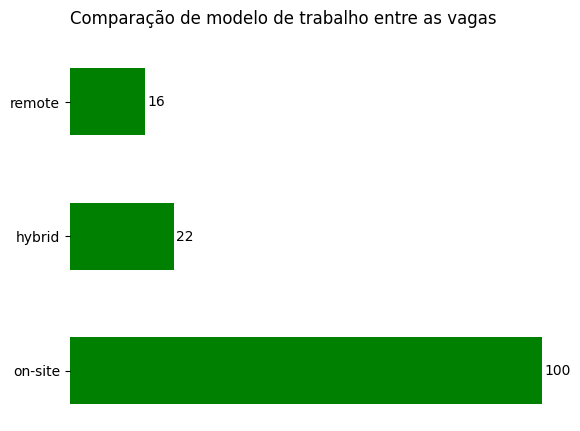

In [244]:
fig, ax = plt.subplots()

counts = df_dados_limpo["workplaceType"].value_counts()

bars = ax.barh(
    counts.index.astype(str),  
    counts.values,              
    color="green",
    height=0.5
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())}',
        va='center',
        ha='left',
        fontsize=10,
        color='black'
    )

ax.set_title('Comparação de modelo de trabalho entre as vagas', loc='left', pad=20)

ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(False)
ax.set_xticks([])

plt.show()

O modelo presencial é amplamente predominante no dataset, representando aproximadamente **72% das vagas**.

Isso pode indicar que:
* muitas empresas ainda priorizam atuação local
* algumas áreas de dados estão integradas a operações presenciais
* ou há limitação da própria plataforma/amostra coletada

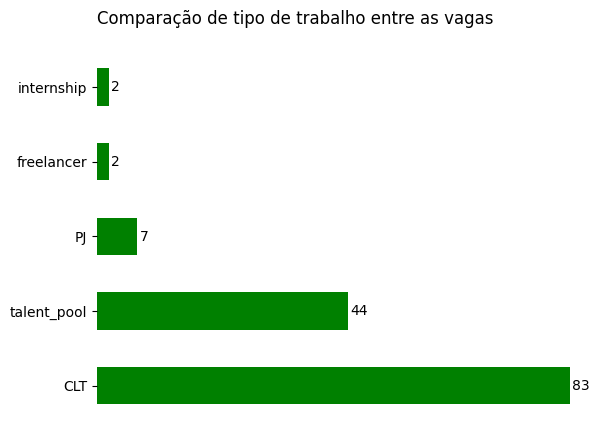

In [245]:
fig, ax = plt.subplots()

counts = df_dados_limpo["type"].value_counts()

bars = ax.barh(
    counts.index.astype(str),  
    counts.values,              
    color="green",
    height=0.5
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())}',
        va='center',
        ha='left',
        fontsize=10,
        color='black'
    )

ax.set_title('Comparação de tipo de trabalho entre as vagas', loc='left', pad=20)

ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(False)
ax.set_xticks([])

plt.show()

O regime **CLT é dominante**, mas há uma presença relevante de vagas em **banco de talentos (44)**.

Isso sugere que:
* parte das vagas pode não representar posições imediatas, mas sim formação de pipeline de candidatos.

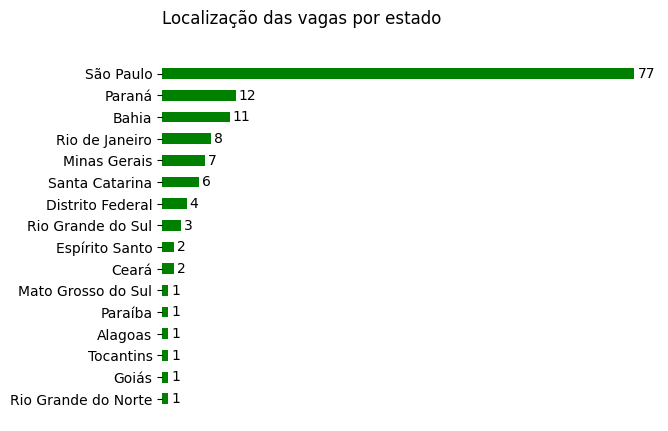

In [246]:
fig, ax = plt.subplots()

counts = df_dados_limpo["state"].value_counts()
counts = counts.sort_values()

bars = ax.barh(
    counts.index.astype(str),  
    counts.values,              
    color="green",
    height=0.5
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())}',
        va='center',
        ha='left',
        fontsize=10,
        color='black'
    )

ax.set_title('Localização das vagas por estado', loc='left', pad=20)

ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(False)
ax.set_xticks([])

plt.show()

Há forte concentração em **São Paulo**, o que pode refletir:
* maior concentração de empresas
* maior adoção da plataforma Gupy na região

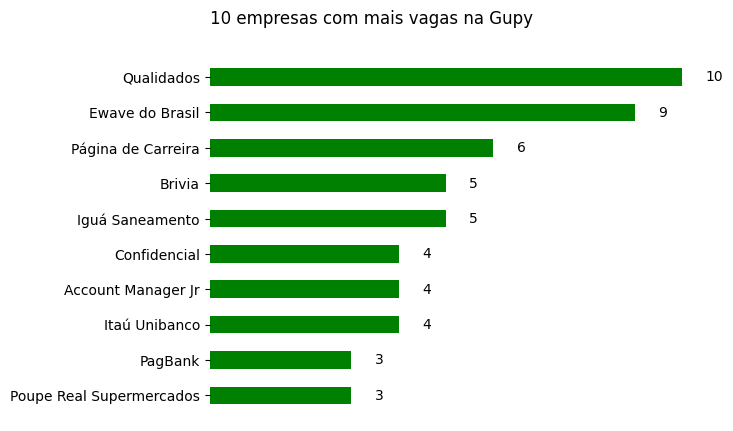

In [247]:
fig, ax = plt.subplots()

counts = df_dados_limpo["careerPageName"].value_counts().head(10)
counts = counts.sort_values()

bars = ax.barh(
    counts.index.astype(str),  
    counts.values,              
    color="green",
    height=0.5
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())}',
        va='center',
        ha='left',
        fontsize=10,
        color='black'
    )

ax.set_title('10 empresas com mais vagas na Gupy', loc='left', pad=20)

ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(False)
ax.set_xticks([])

plt.show()

Não há alta concentração em poucas empresas.
Mesmo as empresas com mais vagas representam uma fração pequena do total, indicando uma distribuição relativamente dispersa entre diferentes organizações.

**Observação importante:**
* A análise está limitada às empresas que utilizam a plataforma Gupy.

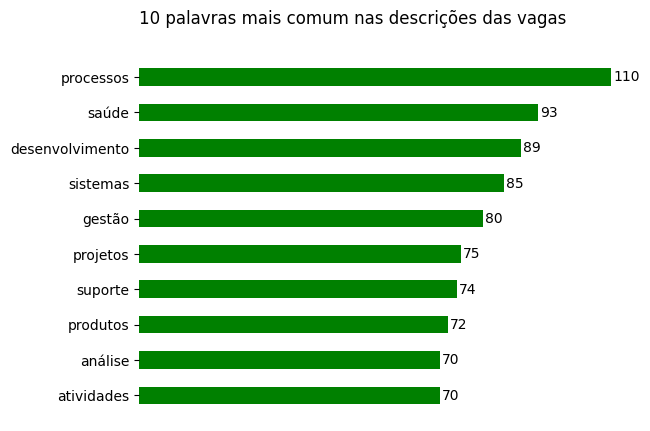

In [248]:
fig, ax = plt.subplots()

counts = pd.Series(words).value_counts().head(10)
counts = counts.sort_values()

bars = ax.barh(
    counts.index.astype(str),  
    counts.values,              
    color="green",
    height=0.5
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())}',
        va='center',
        ha='left',
        fontsize=10,
        color='black'
    )

ax.set_title('10 palavras mais comum nas descrições das vagas', loc='left', pad=20)

ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(False)
ax.set_xticks([])

plt.show()

As descrições indicam que:
* as vagas não são majoritariamente técnicas em análise de dados, mas envolvem atividades operacionais, gestão de processos e suporte.

Também há forte presença de termos como:
* equipe
* comunicação
* experiência
Indicando valorização de soft skills

**Observação:**
* a alta frequência da palavra “saúde” pode indicar concentração de vagas nesse setor específico.

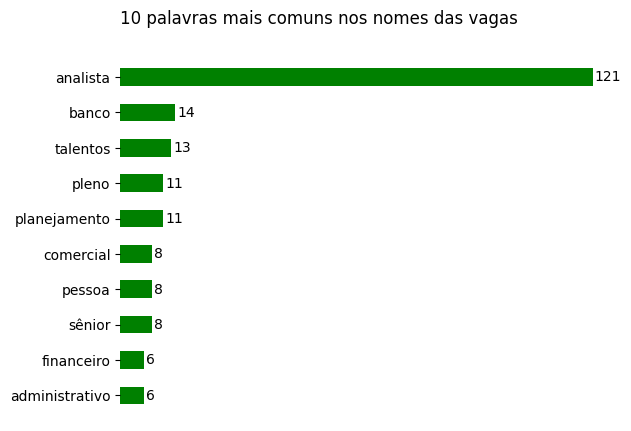

In [249]:
fig, ax = plt.subplots()

counts = pd.Series(words_name).value_counts().head(10)
counts = counts.sort_values()

bars = ax.barh(
    counts.index.astype(str),  
    counts.values,              
    color="green",
    height=0.5
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f'{int(bar.get_width())}',
        va='center',
        ha='left',
        fontsize=10,
        color='black'
    )

ax.set_title('10 palavras mais comuns nos nomes das vagas', loc='left', pad=20)

ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(False)
ax.set_xticks([])

plt.show()

* O termo **“analista” domina**, indicando uso genérico para diferentes funções
* Há presença de níveis (júnior, pleno, sênior), mas não de forma consistente
* A combinação “banco” + “talentos” reforça a presença de vagas não imediatas

### CONCLUSÕES GERAIS
**Como é o mercado de vagas de dados (com base na amostra):**
* Forte predominância de vagas presenciais
* Maioria das vagas em regime CLT
* Alta concentração geográfica em São Paulo
* Presença significativa de bancos de talentos, indicando pipeline de contratação
* Vagas com escopo mais amplo que análise de dados, incluindo:
    * processos
    * gestão
    * suporte
* Baixa ênfase explícita em ferramentas técnicas nas descrições
* Possível concentração em setores específicos, como saúde

**Limitações da análise:**
* Dados coletados apenas da plataforma Gupy
* Amostra limitada (138 vagas)
* Dados representam um recorte temporal específico
* Uso de palavras-chave pode introduzir viés na coleta